# EDA курсора

Абляция показала, что группа `cursor` — самая сильная (без неё CV P@R падает на ~15 п.п.),
хотя в ней всего 5 простых признаков. В этом ноутбуке хотим понять, чем именно поведение курсора ботов
отличается от поведения курсора людей, чтобы сделать признаки точнее.

Курсор есть только на web, поэтому анализируем только web-куки train.
События берём через `clean_events` из `features.py` (окно, без дублей, отсортированы) —
ровно те же, которые отдаем модели.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from features import load_data, clean_events

sns.set_theme(style='whitegrid')
SCREEN_W, SCREEN_H = 1920, 1080

train, test, events = load_data()
ev = clean_events(events, train).merge(train[['cookie_id', 'target']], on='cookie_id')
web = ev[ev.plat == 'web'].copy()
web['has_ptr'] = web.pointer_x.notna()
print('web-событий:', len(web), ' web-куки:', web.cookie_id.nunique())

web-событий: 108382  web-куки: 5917


## 1. Есть ли курсор вообще

Для каждой web-куки считаем долю её событий с координатами (`pointer_share`).
Смотрим распределение этой доли по классам и по семействам клиента.

In [4]:
ck = web.groupby('cookie_id').agg(target=('target', 'first'), ua_fam=('ua_fam', 'first'),
                                  n=('has_ptr', 'size'), pointer_share=('has_ptr', 'mean'))
ck['ptr_cat'] = pd.cut(ck.pointer_share, [-0.01, 0, 0.99, 1], labels=['нет совсем', 'частично', 'всегда'])

print('наличие курсора у куки внутри класса:')
print(pd.crosstab(ck.ptr_cat, ck.target, normalize='columns').round(3))
print()
print('наличие курсора по семействам клиента:')
pd.crosstab([ck.ua_fam, ck.ptr_cat], ck.target)

наличие курсора у куки внутри класса:
target          0      1
ptr_cat                 
нет совсем  0.288  0.573
частично    0.336  0.255
всегда      0.376  0.172

наличие курсора по семействам клиента:


target                         0    1
ua_fam          ptr_cat              
desktop_browser нет совсем  1420  254
                частично    1670  128
                всегда      1872   87
headless        нет совсем    71   56
                частично      77   12
                всегда        63    7
http_lib        нет совсем    43   27
                частично      42   10
                всегда        71    7

In [5]:
# есть ли курсор у разных типов событий
web.groupby('event_name').has_ptr.mean().round(2).sort_values()

event_name
item_view               0.58
search_results_view     0.58
seller_page_view        0.61
contact_chat_open       0.64
contact_message_sent    0.65
contact_phone_show      0.65
photo_swipe             0.65
favorite_add            0.66
login                   0.67
Name: has_ptr, dtype: float64

## 2. Где стоит курсор

Тепловая карта экрана 1920×1080: какая доля всех координат класса попала в каждую клетку.
Если курсор ставится случайно по всему экрану, то очевидно, что карта будет равномерной.

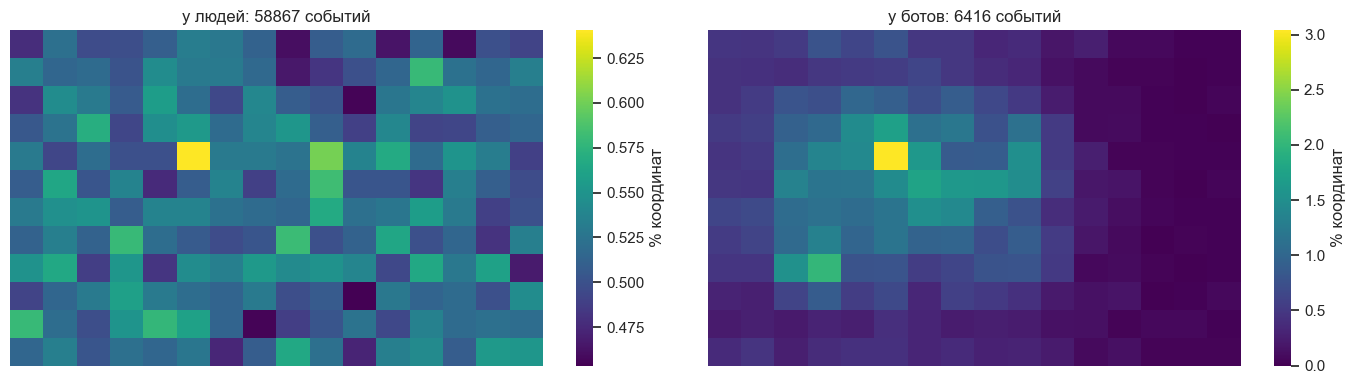

In [9]:
ptr = web[web.has_ptr].copy()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, (y, name) in enumerate([(0, 'у людей'), (1, 'у ботов')]):
    q = ptr[ptr.target == y]
    H, _, _ = np.histogram2d(q.pointer_y, q.pointer_x, bins=[12, 16], range=[[0, SCREEN_H], [0, SCREEN_W]])
    sns.heatmap(H / H.sum() * 100, ax=ax[i], cmap='viridis', cbar_kws={'label': '% координат'},
                xticklabels=False, yticklabels=False)
    ax[i].set_title(f'{name}: {len(q)} событий')
plt.tight_layout(); plt.show()

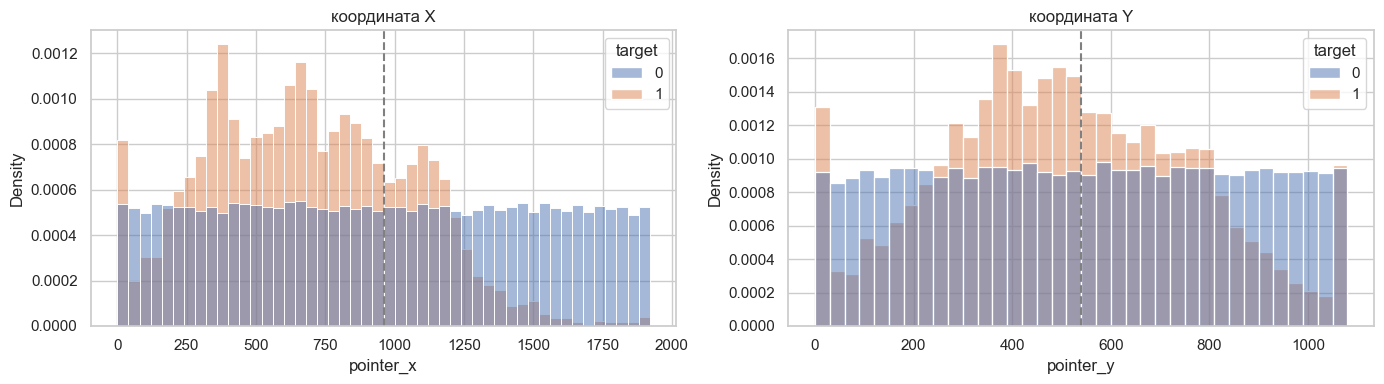

std равномерного:  X 554  Y 312
        pointer_x  pointer_y
target                      
0           554.0      311.0
1           363.0      259.0


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=ptr, x='pointer_x', hue='target', bins=48, stat='density', common_norm=False, ax=ax[0])
ax[0].axvline(SCREEN_W / 2, ls='--', c='gray'); ax[0].set_title('координата X')
sns.histplot(data=ptr, x='pointer_y', hue='target', bins=36, stat='density', common_norm=False, ax=ax[1])
ax[1].axvline(SCREEN_H / 2, ls='--', c='gray'); ax[1].set_title('координата Y')
plt.tight_layout(); plt.show()

# для сравнения: у равномерного распределения на [0, W] std = W / sqrt(12)
print('std равномерного:  X', round(SCREEN_W / np.sqrt(12)), ' Y', round(SCREEN_H / np.sqrt(12)))
print(ptr.groupby('target')[['pointer_x', 'pointer_y']].std().round(0))

## 3. Распределение координат курсора

Для каждой куки с ≥ 5 координатами строим центр масс (средние по x и по y) и разброс (std x, std y).

target
0    3057
1     238
Name: куки с >=5 координатами, dtype: int64


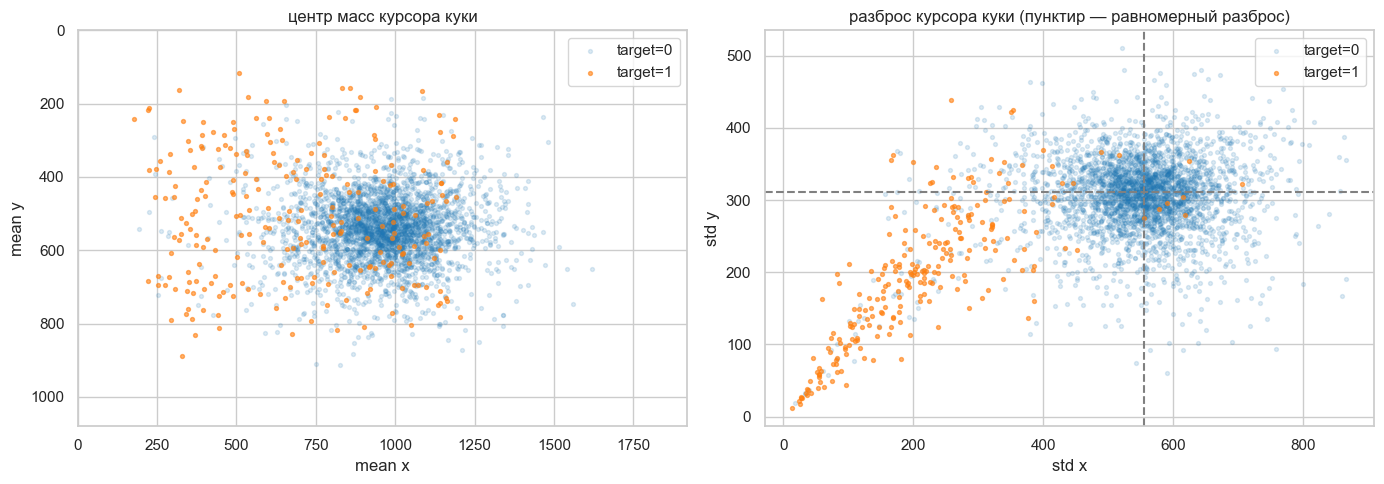

In [12]:
pc = ptr.groupby('cookie_id').agg(target=('target', 'first'), n_ptr=('pointer_x', 'size'),
                                  mx=('pointer_x', 'mean'), my=('pointer_y', 'mean'),
                                  sx=('pointer_x', 'std'), sy=('pointer_y', 'std'))
pc5 = pc[pc.n_ptr >= 5]
print(pc5.target.value_counts().rename('куки с >=5 координатами'))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for y, c, a in [(0, 'tab:blue', 0.15), (1, 'tab:orange', 0.6)]:
    q = pc5[pc5.target == y]
    ax[0].scatter(q.mx, q.my, s=8, c=c, alpha=a, label=f'target={y}')
    ax[1].scatter(q.sx, q.sy, s=8, c=c, alpha=a, label=f'target={y}')
ax[0].set(xlim=(0, SCREEN_W), ylim=(SCREEN_H, 0), title='центр масс курсора куки', xlabel='mean x', ylabel='mean y')
ax[1].axvline(SCREEN_W / np.sqrt(12), ls='--', c='gray'); ax[1].axhline(SCREEN_H / np.sqrt(12), ls='--', c='gray')
ax[1].set(title='разброс курсора куки (пунктир — равномерный разброс)', xlabel='std x', ylabel='std y')
ax[0].legend(); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Передвижение между действиями

Для подряд идущих событий куки, у которых есть курсор, посмотрим, на сколько пикселей он сдвинулся и с какой скоростью он сдивнулся (пиксели / секунды между событиями).

          count   mean    std  min    25%    50%     75%     max
target                                                          
0       55072.0  789.0  418.0  1.0  464.0  745.0  1068.0  2077.0
1        6165.0  336.0  260.0  2.0  135.0  278.0   470.0  1743.0

доля шагов без движения (step == 0):
target
0    0.0
1    0.0
Name: step, dtype: float64


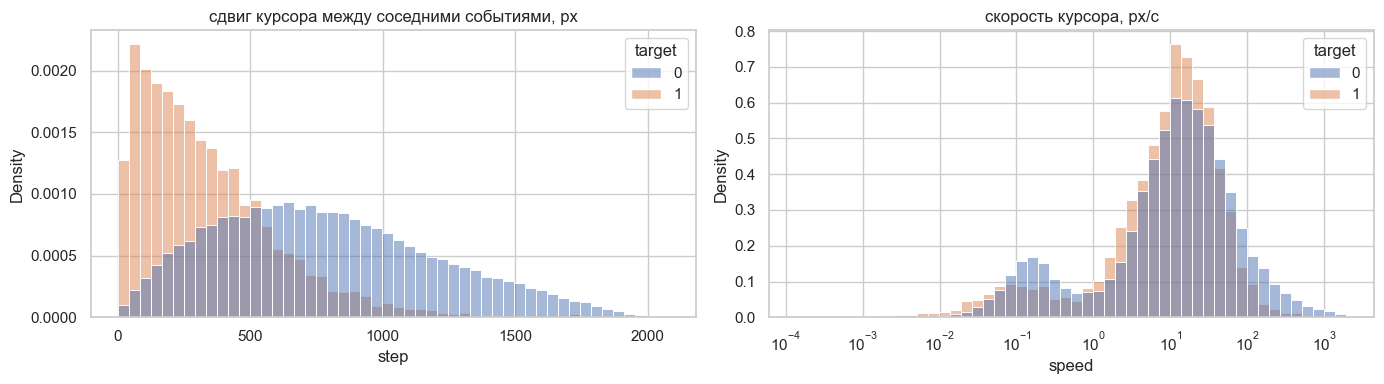

In [13]:
g = ptr.groupby('cookie_id')
ptr['step'] = np.hypot(g.pointer_x.diff(), g.pointer_y.diff())
ptr['step_dt'] = g.event_ts.diff().dt.total_seconds()
ptr['speed'] = ptr.step / ptr.step_dt.replace(0, np.nan)

print(ptr.groupby('target').step.describe().round(0))
print()
print('доля шагов без движения (step == 0):')
print(ptr.groupby('target').step.apply(lambda s: (s == 0).mean()).round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=ptr, x='step', hue='target', bins=50, stat='density', common_norm=False, ax=ax[0])
ax[0].set_title('сдвиг курсора между соседними событиями, px')
sns.histplot(data=ptr[ptr.speed > 0], x='speed', hue='target', log_scale=True, bins=50,
             stat='density', common_norm=False, ax=ax[1])
ax[1].set_title('скорость курсора, px/с')
plt.tight_layout(); plt.show()

## 5. Положение курсора для каждого типа события

Строим медианное положение курсора по типам событий у ботов и у людей.

In [9]:
med = ptr.groupby(['event_name', 'target'])[['pointer_x', 'pointer_y']].median().unstack('target').round(0)
med.columns = [f'{c}_{"bot" if t else "human"}' for c, t in med.columns]
med

,pointer_x_human,pointer_x_bot,pointer_y_human,pointer_y_bot
event_name,,,,
contact_chat_open,913.0,570.0,515.0,490.0
contact_message_sent,941.0,560.0,523.0,308.0
contact_phone_show,931.0,687.0,559.0,459.0
favorite_add,954.0,656.0,537.0,500.0
item_view,957.0,679.0,545.0,499.0
login,968.0,700.0,536.0,479.0
photo_swipe,956.0,651.0,558.0,538.0
search_results_view,955.0,659.0,538.0,490.0
seller_page_view,950.0,692.0,541.0,479.0


In [15]:
# координаты, кратные 10-ти по обеим осям
ptr['round10'] = (ptr.pointer_x % 10 == 0) & (ptr.pointer_y % 10 == 0)
print('доля координат, кратных 10 по обеим осям (при случайном движении курсора ожидаемо 1%):')
print(ptr.groupby('target').round10.mean().round(4))

доля координат, кратных 10 по обеим осям (при случайном движении курсора ожидаемо 1%):
target
0    0.0094
1    0.0198
Name: round10, dtype: float64
